In [37]:
import pandas as pd

df=pd.read_csv('../data/cleaned_housePrice_enhanced.csv')

df = pd.get_dummies(df, columns=['Address'], drop_first=True)





In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# بارگذاری داده
df = pd.read_csv('../data/cleaned_housePrice_enhanced.csv')

# انتخاب هدف (price)
y = df['Price']
X=df[['Area', 'Room']]  

# تبدیل True/False به 1/0
#bool_cols = ['Parking', 'Warehouse', 'Elevator']
#X[bool_cols] = X[bool_cols].astype(int)

# تبدیل Address به One-Hot Encoding
#X = pd.get_dummies(X, columns=['Address'], drop_first=True)

# تقسیم داده‌ها
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression:")
print("R²:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression:
R²: 0.4080370642441423
MAE: 2687583335.3900094
RMSE: 5070041818.388039


In [40]:
print("\nData types and shapes:")
print("y_test dtype:", y_test.dtype)
print("y_test shape:", y_test.shape)
print("y_pred_lr dtype:", y_pred_lr.dtype)
print("y_pred_lr shape:", y_pred_lr.shape)
print("\nSample values:")
print("y_test first 5:", y_test.head())
print("y_pred_lr first 5:", y_pred_lr[:5])


Data types and shapes:
y_test dtype: float64
y_test shape: (613,)
y_pred_lr dtype: float64
y_pred_lr shape: (613,)

Sample values:
y_test first 5: 1241    8.750000e+08
203     1.200000e+09
1260    4.450000e+09
1626    6.500000e+08
1578    6.700000e+08
Name: Price, dtype: float64
y_pred_lr first 5: [1.41823574e+08 3.05699106e+09 4.76882497e+09 3.91290801e+09
 8.25460375e+09]


In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest:")
print("R²:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

importances = model.feature_importances_
for col, imp in zip(X_train.columns, importances):
    print(f"{col}: {imp:.3f}")



Random Forest:
R²: 0.7616035632561458
MAE: 1836649791.750606
RMSE: 3217467462.711791
Area: 0.923
Room: 0.077


XGBoost:
R²: 0.8083132170479794
MAE: 1767988349.1810768
RMSE: 2885096661.1991158
Area: 0.763
Room: 0.237


<Figure size 1200x800 with 0 Axes>

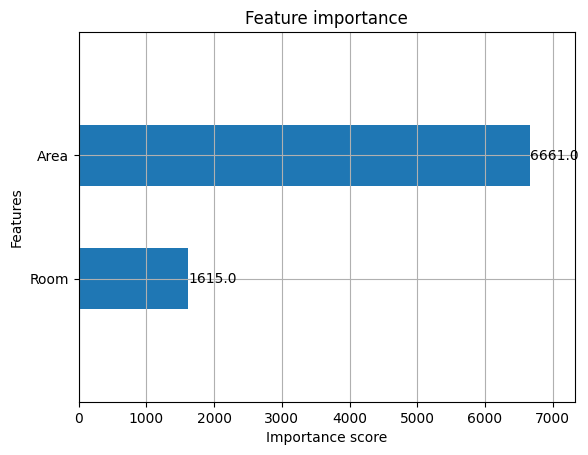

In [42]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost:")
print("R²:", r2_score(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

import matplotlib.pyplot as plt
from xgboost import plot_importance

# چاپ feature importance به صورت عددی
importances = xgb.feature_importances_
for col, imp in zip(X_train.columns, importances):
    print(f"{col}: {imp:.3f}")

# یا نمایش گرافیکی
plt.figure(figsize=(12,8))
plot_importance(xgb, max_num_features=15, height=0.5)
plt.show()


In [43]:
import joblib
joblib.dump(xgb, '../models/house_price_model.pkl')


['../models/house_price_model.pkl']